In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import os
import joblib

# Downloads the Kaggle dataset and defines the access path.
# This path will be used to locate the CSV file of the dataset.
path = kagglehub.dataset_download("jackksoncsie/spam-email-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'spam-email-dataset' dataset.
Path to dataset files: /kaggle/input/spam-email-dataset


In [ ]:
# Initializes the df_email DataFrame to None for robust error handling.
df_email = None

try:
    # Loads the 'emails.csv' CSV file, specifying 'latin-1' encoding to handle special characters.
    file_path_email = os.path.join(path, 'emails.csv')
    df_email = pd.read_csv(file_path_email, encoding='latin-1')
    print("Email data overview :")
    print(df_email.head()) # Displays the first rows of the DataFrame for a quick overview.
    print("\nAvailable column names in the email dataset :")
    print(df_email.columns.tolist()) # Lists all columns present in the DataFrame.
except FileNotFoundError:
    print(f"Error: The email dataset file was not found at {file_path_email}. Please check the path or download.")
    df_email = None
except Exception as e:
    print(f"An unexpected error occurred while loading the file: {e}")
    df_email = None

Email data overview :
                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1

Available column names in the email dataset :
['text', 'spam']


In [ ]:
if df_email is not None:
    # Renames the 'spam' column to 'label' for better clarity.
    df_email = df_email.rename(columns={'spam': 'label'})
    # Creates a 'label_num' column which is a numerical copy of 'label' (0 for non-spam, 1 for spam).
    df_email['label_num'] = df_email['label']

    # Defines the features (X = email text) and labels (y = spam/non-spam status).
    X = df_email['text']
    y = df_email['label_num']

    # Initializes the TfidfVectorizer to convert texts into a numerical feature matrix.
    # 'stop_words'='english' removes common English words (e.g., 'the', 'is'), 'max_features' limits the vocabulary size.
    tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
    # Applies the vectorizer to transform the text into numerical features.
    X_transformed = tfidf.fit_transform(X)
else:
    print("Preprocessing and vectorization are skipped because the DataFrame was not loaded.")

In [ ]:
if df_email is not None:
    # Splits the transformed data into training (80%) and test (20%) sets.
    # 'random_state' ensures reproducibility of the split.
    X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)

    # Initializes and trains a Logistic Regression model, a linear classification algorithm.
    # 'max_iter=1000' is increased to ensure algorithm convergence.
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
else:
    print("Data splitting and model training are skipped.")


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       856
           1       0.99      0.95      0.97       290

    accuracy                           0.98      1146
   macro avg       0.99      0.97      0.98      1146
weighted avg       0.98      0.98      0.98      1146


--- Confusion Matrix ---


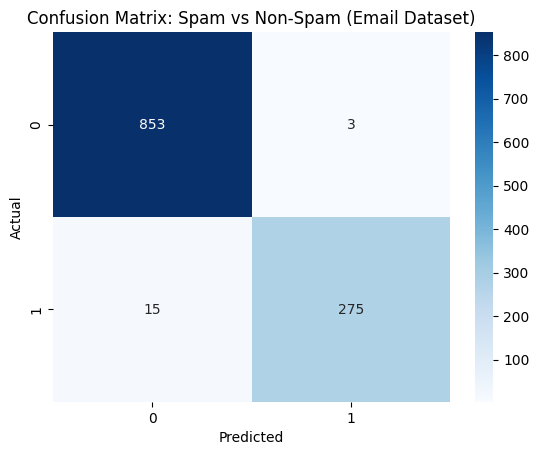

In [ ]:
if df_email is not None:
    # Makes predictions on the test set.
    y_pred = model.predict(X_test)

    print("\n--- Classification Report ---")
    # Displays a detailed report of the model's performance (precision, recall, f1-score).
    print(classification_report(y_test, y_pred))

    print("\n--- Confusion Matrix ---")
    # Computes the confusion matrix to visualize true positives/negatives and false positives/negatives.
    conf_mat = confusion_matrix(y_test, y_pred)
    # Displays the confusion matrix as a heatmap for better readability.
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix: Spam vs Non-Spam (Email Dataset)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
else:
    print("Model evaluation is skipped.")

In [ ]:
if df_email is not None:
    # Defines a function to predict if an email is SPAM or NON-SPAM.
    def predict_email(message):
        # Vectorizes the input message using the trained TfidfVectorizer.
        message_vec = tfidf.transform([message])
        # Makes the prediction with the logistic regression model.
        prediction = model.predict(message_vec)
        # Returns "SPAM" if the prediction is 1, otherwise "NON-SPAM".
        return "SPAM" if prediction[0] == 1 else "NON-SPAM"

    # Concrete examples to test the prediction function.
    new_email_spam = "Congratulations! You've won a $1,000,000 cash prize. Text CLAIM to 12345 to collect."
    print(f"\nMessage : '{new_email_spam}' \nClassification : {predict_email(new_email_spam)}")

    new_email_ham = "Hey, let's meet up for coffee tomorrow at 10 AM."
    print(f"Message : '{new_email_ham}' \nClassification : {predict_email(new_email_ham)}")
else:
    print("Manual testing is skipped because the model has not been trained.")


Message : 'Congratulations! You've won a $1,000,000 cash prize. Text CLAIM to 12345 to collect.' 
Classification : SPAM
Message : 'Hey, let's meet up for coffee tomorrow at 10 AM.' 
Classification : NON-SPAM


In [ ]:
# Saves the trained Logistic Regression model to a file.
joblib.dump(model, 'logistic_regression_model.joblib')
print("The Logistic Regression model has been saved as 'logistic_regression_model.joblib'")

# Saves the trained TfidfVectorizer object to a file.
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
print("The TfidfVectorizer has been saved as 'tfidf_vectorizer.joblib'")

The Logistic Regression model has been saved as 'logistic_regression_model.joblib'
The TfidfVectorizer has been saved as 'tfidf_vectorizer.joblib'
